# Analyzing and Predicting Passenger Flow to Ireland based on Air and Sea Travel Trends Across Time and Regions.

## Data preparation

Here I selected the dataset

(https://data.cso.ie/table/ASA03)

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import kurtosis,uniform,normaltest,binom,poisson
from sklearn.preprocessing import PolynomialFeatures
import sklearn.preprocessing as preproc

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV

import warnings
warnings.filterwarnings('ignore')

- Here I have imported all pakages and libraries

Now import the dataset

In [49]:
df=pd.read_csv("ASA03.20250320T230345.csv")

I have imported the dataset and this dataset saved in a variable as df

In [50]:
df.head()

,STATISTIC Label,Year,Country,Direction,UNIT,VALUE
0,Air and Sea Travel,2010,All countries,Arrivals,Thousand,12902.2
1,Air and Sea Travel,2010,All countries,Departures,Thousand,12920.2
2,Air and Sea Travel,2010,United Arab Emirates,Arrivals,Thousand,99.0
3,Air and Sea Travel,2010,United Arab Emirates,Departures,Thousand,99.0
4,Air and Sea Travel,2010,Austria,Arrivals,Thousand,65.3


It shows top 5 rows

In [51]:
df.shape

(1200, 6)

shape is an attribute of a pandas DataFrame, it counts the number of rows and columns
- rows are 1200
- columns are 6

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   STATISTIC Label  1200 non-null   object 
 1   Year             1200 non-null   int64  
 2   Country          1200 non-null   object 
 3   Direction        1200 non-null   object 
 4   UNIT             1200 non-null   object 
 5   VALUE            1200 non-null   float64
dtypes: float64(1), int64(1), object(4)
memory usage: 56.4+ KB


df.info() is a method pandas that provides a summary of a DataFrame

First I will check is there any null values in a dataset

In [53]:
df.dtypes

STATISTIC Label     object
Year                 int64
Country             object
Direction           object
UNIT                object
VALUE              float64
dtype: object

The Year column is an integer (int64), which is suitable to represent years. In the VALUE column, the float64 type suggests the passenger counts have decimal representation, allowing more precision in calculations. The rest of the columns STATISTIC Label, Country, Direction, and UNIT are of object type. 

In [54]:
df.isnull().sum()

STATISTIC Label    0
Year               0
Country            0
Direction          0
UNIT               0
VALUE              0
dtype: int64

No missing Values on columns

In [55]:
df.nunique()

STATISTIC Label      1
Year                15
Country             40
Direction            2
UNIT                 1
VALUE              930
dtype: int64

In [56]:
df['VALUE(Thousand)']=df['VALUE'].astype('int64')

In [57]:
df['VALUE(Thousand)'].dtype

dtype('int64')

Here I have changed float to integer and stored in a 'VALUE(Thousand)' variable

Now I remove unwanted columns

In [58]:
col=['STATISTIC Label','UNIT','VALUE']

In [59]:
df=df.drop(columns=col)
df.head()

,Year,Country,Direction,VALUE(Thousand)
0,2010,All countries,Arrivals,12902
1,2010,All countries,Departures,12920
2,2010,United Arab Emirates,Arrivals,99
3,2010,United Arab Emirates,Departures,99
4,2010,Austria,Arrivals,65


Dropping the "STATISTIC Label" and "UNIT" columns makes the dataset more concise in analyzing the remaining relevant attributes: year, country, travel direction, and Value(Thousand). Being that there was only one unique value for the STATISTIC Label, and the UNIT was a constant in terms of values, these columns do not contribute any further value to the analytical work on this dataset. 

In [60]:
df.duplicated().sum()

0

The dataset is free from duplicated rows

## EDA (Exploratory data analysis)

### Categorical Analysis

In [61]:
num=[]
cat=[]
data_types=df.dtypes
dict1=dict(data_types)
for i in dict1:
    if dict1[i]=='O':
        cat.append(i)
    else:
        num.append(i)
print(len(num))
print(len(cat))
num,cat

2
2


(['Year', 'VALUE(Thousand)'], ['Country', 'Direction'])

In [62]:
cat

['Country', 'Direction']

separates numerical and categorical columns from a DataFrame df

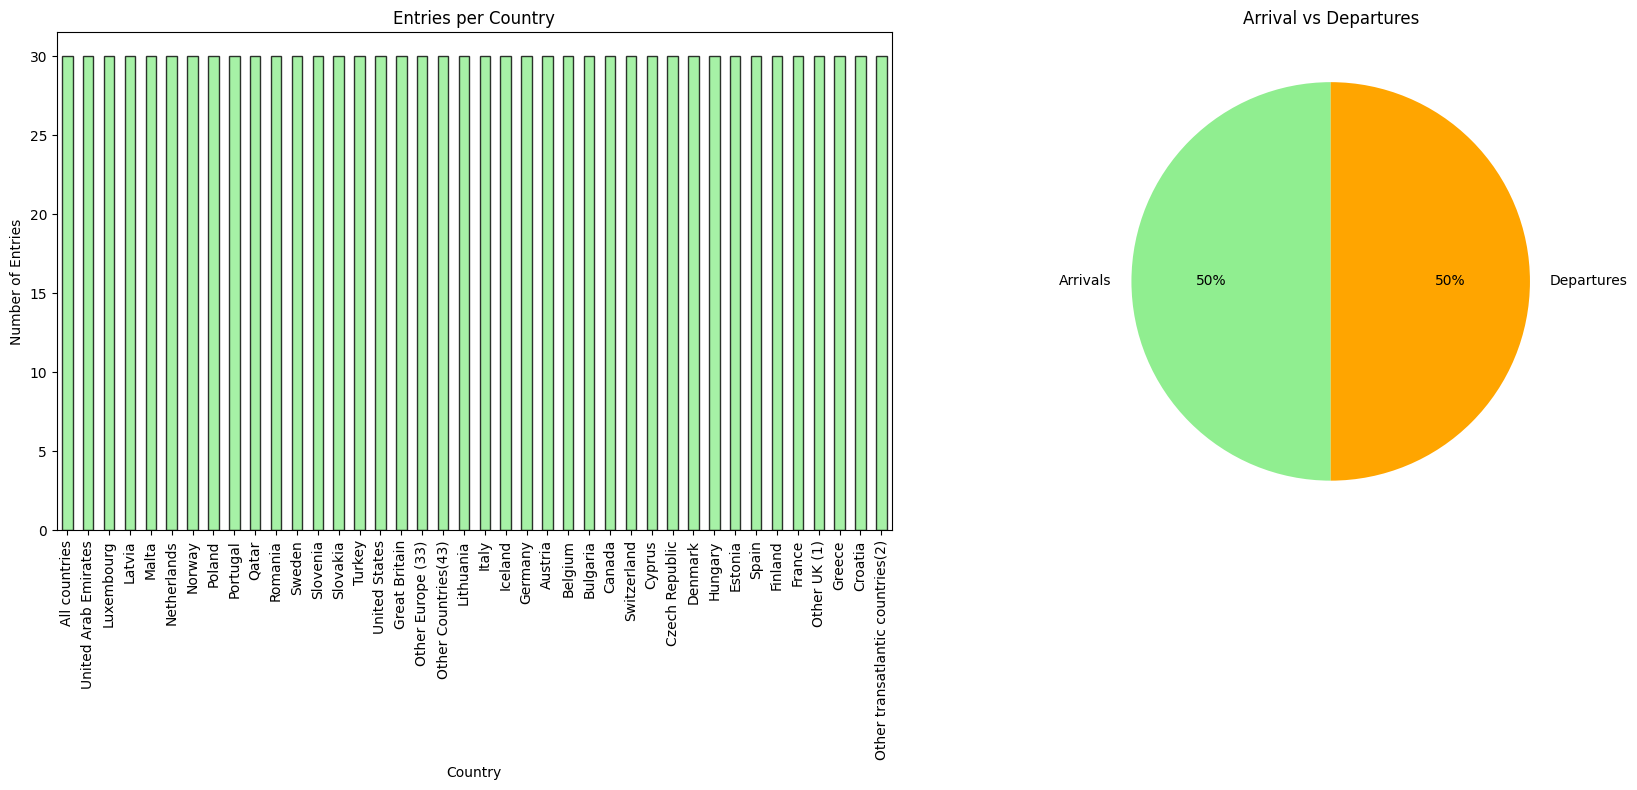

In [63]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

df['Country'].value_counts().plot(  
    kind='bar', color='lightgreen', edgecolor='black', alpha=0.8, ax=axes[0])

axes[0].set(title="Entries per Country", xlabel="Country", ylabel="Number of Entries")

df['Direction'].value_counts().plot.pie(
    autopct='%0.f%%', startangle=90, colors=['lightgreen', 'orange'], ax=axes[1])

axes[1].set(title="Arrival vs Departures", ylabel='')

plt.tight_layout()
plt.show()

# plt.savefig('Bar_&_Pie(Cat).png')
# plt.close()

creates a bar chart of country counts from df, styling it with colors, bold labels, rotated x-axis text for readability creates a visually appealing pie chart with distinct colors and clear labels

#### Numerical Data Analysis

In [64]:
num

['Year', 'VALUE(Thousand)']

In [65]:
df['VALUE(Thousand)'].describe()

count     1200.000000
mean       758.862500
std       2654.709756
min          0.000000
25%         29.000000
50%         75.000000
75%        266.250000
max      21458.000000
Name: VALUE(Thousand), dtype: float64

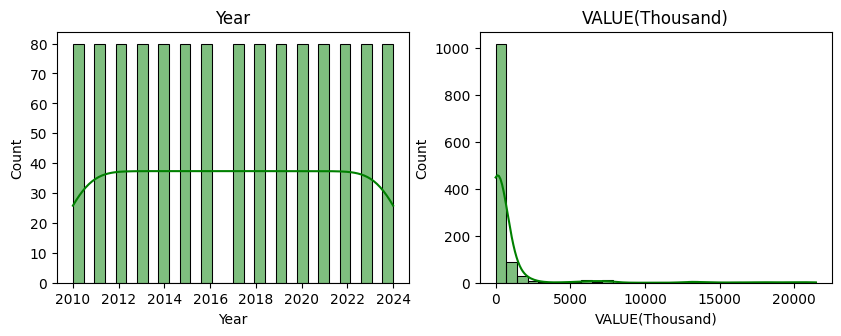

In [66]:
plt.figure(figsize=(10, 15))

for i, column in enumerate(num):
    plt.subplot(4, 2, i+1)
    plt.title(column)
    sns.histplot(df[column], bins=30, kde=True, color='green')

plt.show()
# plt.savefig('HISTOGRAM(Num)1.png')
# plt.close()

1st graph 
- created a histogram of the "Year" column using Seaborn, with a kernel density estimate (kde=True)

2nd graph 
- creates a histogram with a KDE plot to visualize the distribution of 'VALUE', with a kernel density estimate (kde=True)

### Box plot

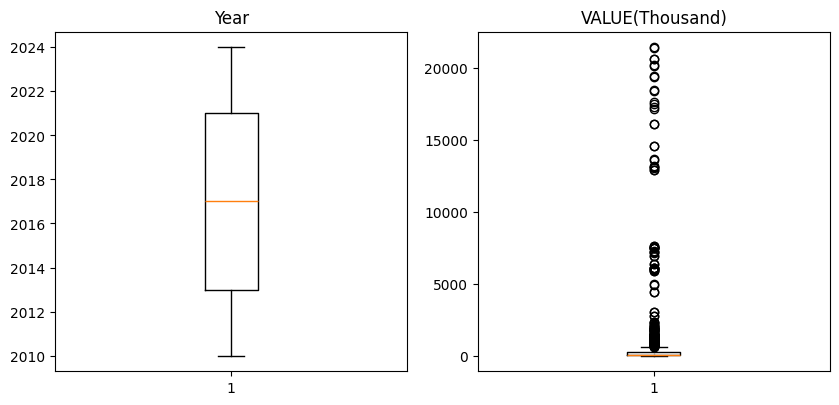

In [67]:
plt.figure(figsize=(10,15))
for i,column in enumerate(num):
    plt.subplot(3,2,i+1)
    plt.title(column)
    plt.boxplot(df[column])
plt.show()

# plt.savefig('Boxplot(Col).png')
# plt.close()

Here I have done Box plot for the columns Year and VALUE(Thousand)

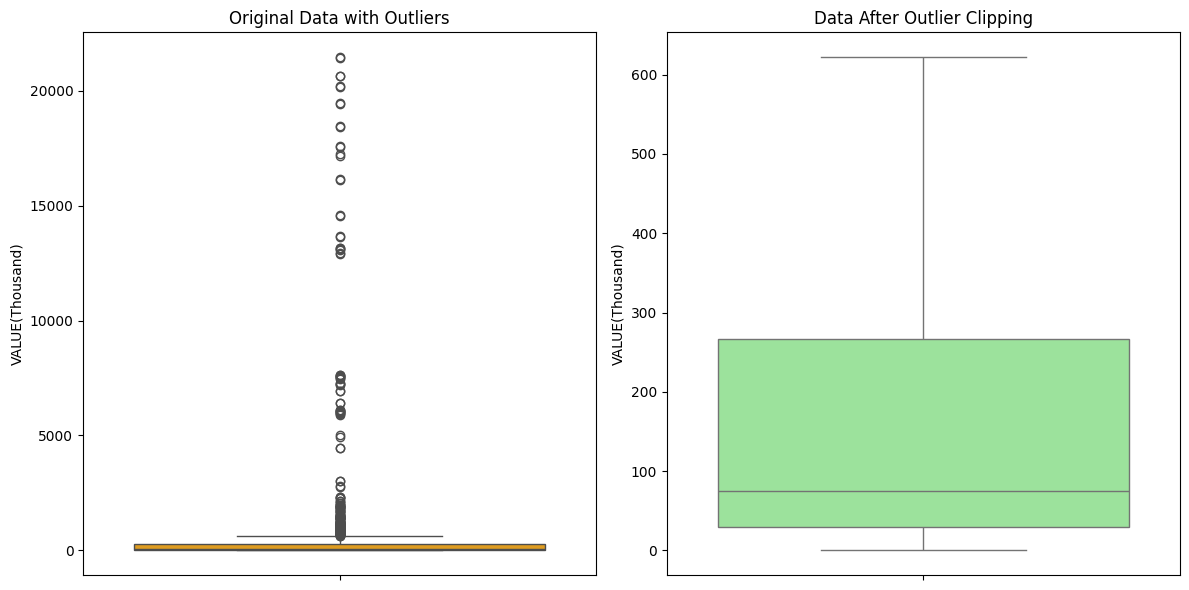

In [68]:
q1 = np.quantile(df['VALUE(Thousand)'], 0.25)
q3 = np.quantile(df['VALUE(Thousand)'], 0.75)
iqr = q3 - q1

ub = q3 + (1.5 * iqr)
lb = q1 - (1.5 * iqr)

df1 = np.clip(df['VALUE(Thousand)'], lb, ub)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)  
sns.boxplot(y=df['VALUE(Thousand)'],color='orange')
plt.title('Original Data with Outliers')

plt.subplot(1, 2, 2) 
sns.boxplot(y=df1,color='lightgreen')
plt.title('Data After Outlier Clipping')

plt.tight_layout()  
plt.show()

# plt.savefig('Outliers_with&without.png')
# plt.close()

This code **identifies and removes outliers** from the `'VALUE'` column using the **Interquartile Range (IQR) method**, then compares the original and clipped data with **side-by-side boxplots** to visualize the effect of outlier removal.

### both categorical and Numerical Columns

In [69]:
total_travel = df.pivot_table(index='Year', columns='Direction', values='VALUE(Thousand)')
total_travel

Direction,Arrivals,Departures
Year,,
2010,644.700,645.600
2011,652.075,655.025
2012,656.725,657.700
2013,681.125,682.325
2014,726.900,728.025
2015,804.600,806.475
2016,876.200,880.125
2017,919.550,922.025
2018,969.300,972.375


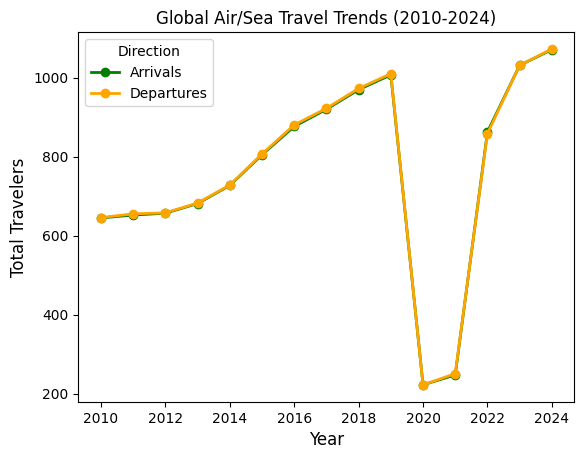

In [25]:
total_travel.plot(marker='o', linewidth=2, color=['green', 'orange']) 

plt.title('Global Air/Sea Travel Trends (2010-2024)', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Travelers', fontsize=12)
plt.legend(title='Direction', fontsize=10)
plt.show()

# plt.savefig('Travel_Trends.png')
# plt.close()

Creates a pivot table where `'Year'` is the index, `'Direction'` categories are columns, and `'VALUE'` represents the data, summarizing travel trends over time and ploted.

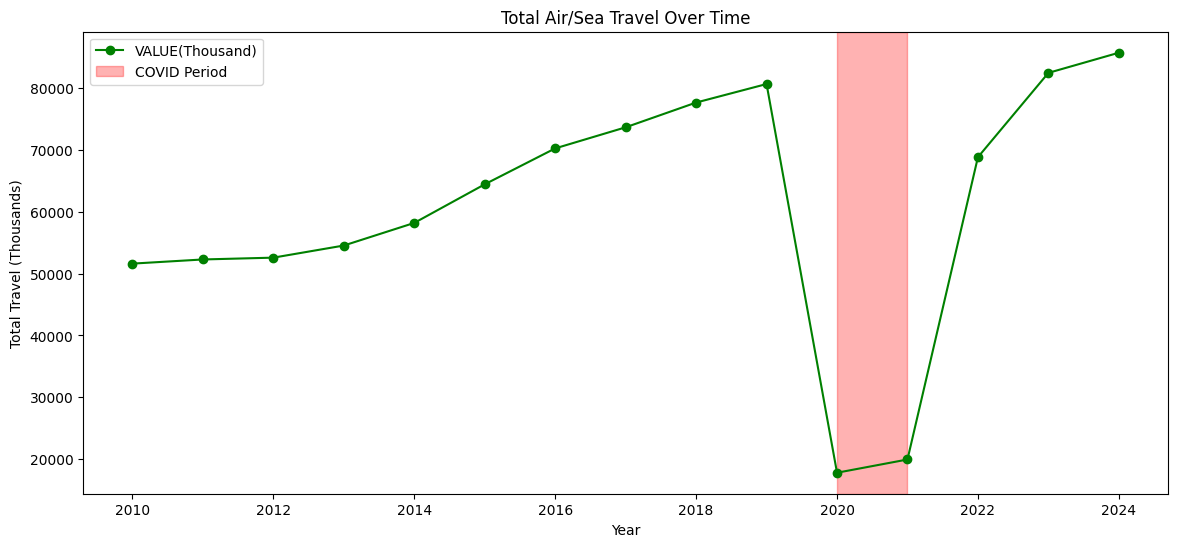

In [32]:
plt.figure(figsize=(14,6))
df.groupby('Year')['VALUE(Thousand)'].sum().plot(marker='o',color='green')
plt.title('Total Air/Sea Travel Over Time')
plt.ylabel('Total Travel (Thousands)')
plt.axvspan(2020, 2021, color='red', alpha=0.3, label='COVID Period')
plt.legend()
plt.show()

# plt.savefig('Travel_over_time_COVID.png')
# plt.close()

**line graph** visualizes the **total travel in thousands from 2010 to 2024**. We observe steadily rising travel volumes up until 2019, followed by a sharp fall in 2020, marking the beginning of COVID-19. The area shaded pink denotes the pandemic period, during which traveling was reduced remarkably. As of 2021, the travel volume essentially recovers highly and exceeds previous travel at equal rates in 2023 and 2024.

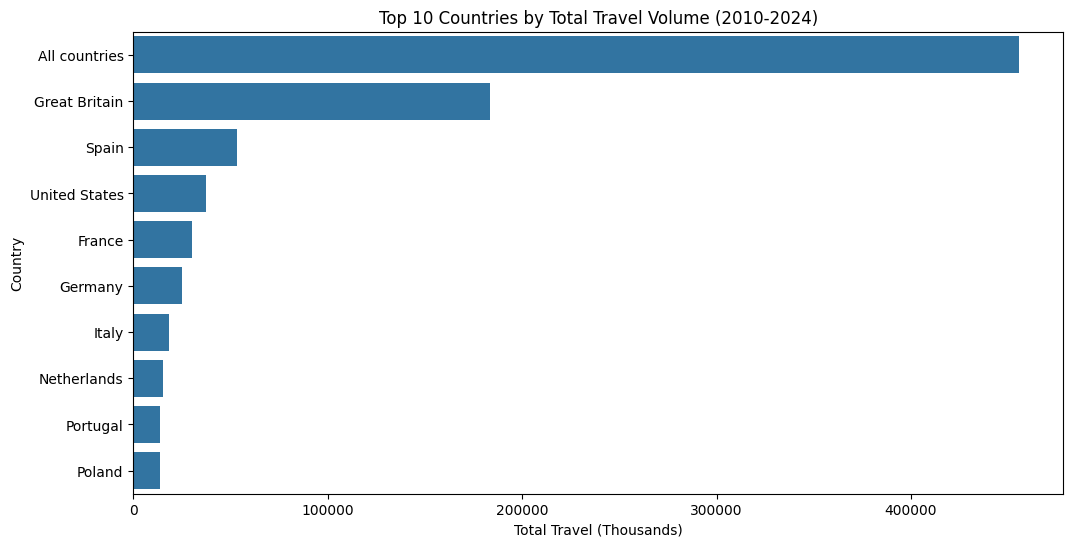

In [33]:
top_countries = df.groupby('Country')['VALUE(Thousand)'].sum().nlargest(10)
plt.figure(figsize=(12,6))
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title('Top 10 Countries by Total Travel Volume (2010-2024)')
plt.xlabel('Total Travel (Thousands)')
plt.show()

# plt.savefig('Travel_Volume_top_countries.png')
# plt.close()

bar chart shows top 10 countries by total travel volume using the 'VALUE' column, then visualizes the results with a horizontal bar plot, where the x-axis represents total travel volume and the y-axis lists the top 10 countries, making it easy to compare travel activity across nations.

***Correlation***

In [34]:
numerical_df = df[['Year', 'VALUE(Thousand)']]
corr_matrix = numerical_df.corr()
corr_matrix

,Year,VALUE(Thousand)
Year,1.000000,0.020451
VALUE(Thousand),0.020451,1.000000


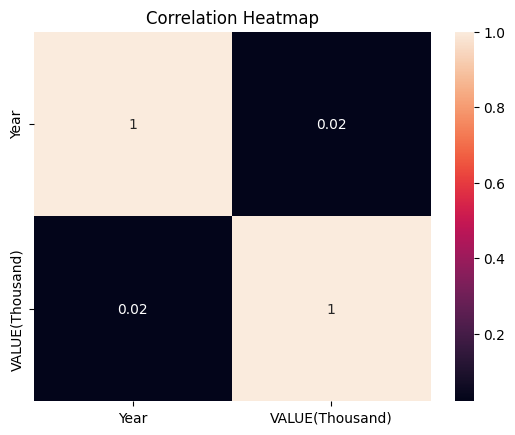

In [35]:
sns.heatmap(corr_matrix, annot=True)
plt.title('Correlation Heatmap')
plt.show()

# plt.savefig('correlation_heatmap_num.png')
# plt.close()

This code extracts numerical columns ('Year' and 'VALUE'), calculates their correlation matrix, and visualizes it using a heatmap with annotations, helping to identify the strength and direction of relationships between these variables. 

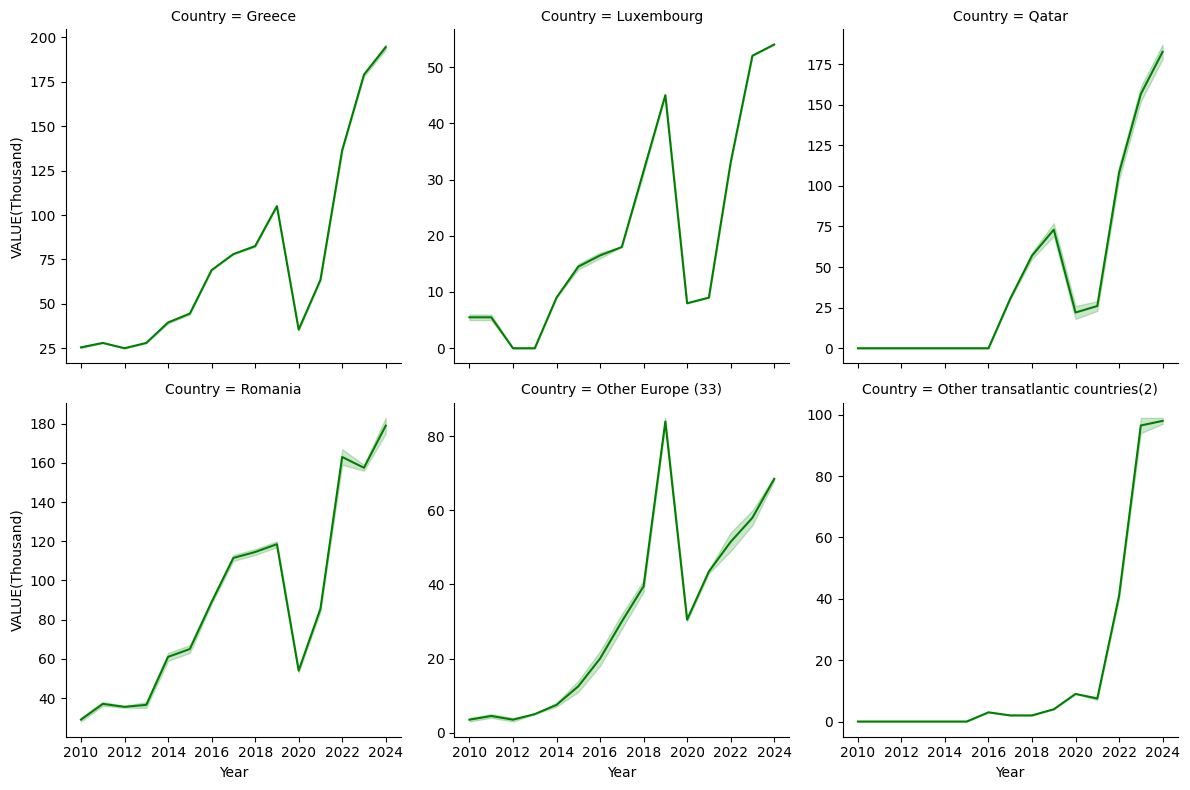

In [36]:
correlations = df.groupby('Country')[['Year', 'VALUE(Thousand)']].corr().unstack().iloc[:, 1]

top_countries = correlations.abs().nlargest(6).index  

filtered_df = df[df['Country'].isin(top_countries)]

g = sns.FacetGrid(filtered_df, col='Country', col_wrap=3, height=4, sharey=False)
g.map_dataframe(sns.lineplot, x='Year', y='VALUE(Thousand)', color='green')

plt.show()

# plt.savefig('FaceGrid_top6.png')
# plt.close()

This code calculates country-wise correlations between `'Year'` and `'VALUE'`, selects the **top 6 countries** with the strongest absolute correlation, filters the dataset accordingly, and visualizes the trends using **FacetGrid** with separate subplots. (**FacetGrid** easy to compare trends across different categories.)

### Statistical Analysis

In [37]:
df['VALUE(Thousand)'].describe()

count     1200.000000
mean       758.862500
std       2654.709756
min          0.000000
25%         29.000000
50%         75.000000
75%        266.250000
max      21458.000000
Name: VALUE(Thousand), dtype: float64

The statistical summary of the column "VALUE (Thousand)" in the dataset provides insights into the distribution of travel volumes. 
- The dataset contains 1,200 data points, with an average travel volume of approximately 758.86 thousand. 
- The standard deviation is quite high at 2,654.71, indicating a wide spread of values. 
- The minimum value is 0, suggesting some instances where no travel occurred. 
- The first quartile (25%) is at 29 thousand, 
- the median (50%) is 75 thousand, 
- the third quartile (75%) is 266.25 thousand, indicating that most data points are concentrated in the lower range.
- the maximum value reaches 21,458 thousand.


In [38]:
yearly_stats = df.groupby('Year')['VALUE(Thousand)'].agg(['mean', 'median', 'std'])

# Print the yearly statistics
print(yearly_stats)


           mean  median          std
Year                                
2010   645.1500    63.0  2204.236135
2011   653.5500    61.0  2228.020697
2012   657.2125    60.0  2226.535850
2013   681.7250    59.0  2302.546064
2014   727.4625    66.0  2455.567221
2015   805.5375    70.5  2709.507428
2016   878.1625    80.5  2949.241981
2017   920.7875    82.0  3074.810241
2018   970.8375    95.0  3222.768589
2019  1008.3000   111.5  3334.243844
2020   222.3000    30.5   742.047909
2021   249.0500    36.0   816.011260
2022   860.3875   113.5  2822.624075
2023  1030.8625   129.5  3382.395147
2024  1071.6125   138.5  3506.445929


In [40]:
kurtosis_values

{'Year': -1.210714285714286, 'VALUE(Thousand)': 32.62183038797246}

***Kurtosis***

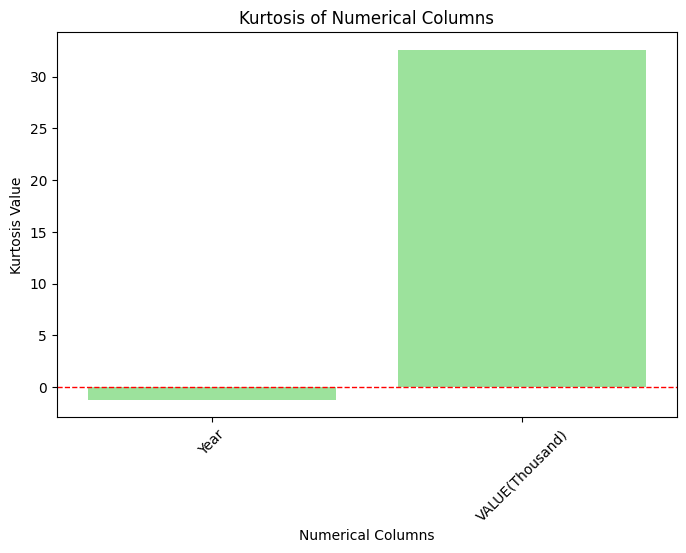

In [39]:
from scipy.stats import kurtosis

# Step 1: Compute kurtosis for each numerical column
kurtosis_values = {col: kurtosis(df[col], fisher=True) for col in num}

# Step 2: Create a bar plot
plt.figure(figsize=(8, 5))
sns.barplot(x=list(kurtosis_values.keys()), y=list(kurtosis_values.values()), color="lightgreen")

# Step 3: Add labels and title
plt.xlabel("Numerical Columns")
plt.ylabel("Kurtosis Value")
plt.title("Kurtosis of Numerical Columns")
plt.axhline(0, color='red', linestyle='dashed', linewidth=1)  # Reference line at 0 (normal distribution)

# Step 4: Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Step 5: Show the plot
plt.show()

# plt.savefig('Kurtosis_num.png')
# plt.close()

The code computes the kurtosis for all numerical columns in the DataFrame and visualizes the results as a bar chart.

 ***QQ plot***

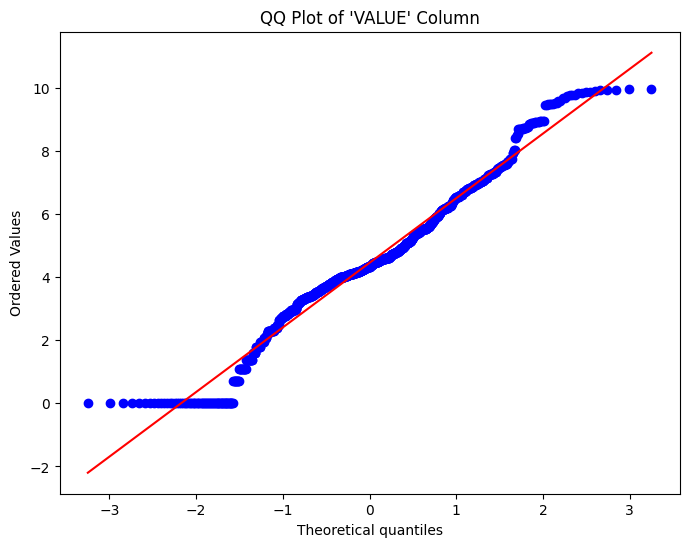

In [41]:
df_log = np.log1p(df["VALUE(Thousand)"])

plt.figure(figsize=(8, 6))
stats.probplot(df_log, dist="norm", plot=plt)

plt.title("QQ Plot of 'VALUE' Column")
plt.show()

# plt.savefig('QQ_Plot.png')
# plt.close()

This QQ plot displays the distribution of log-transformed values as compared to a theoretical quantities. The blue dots are the actual data points and the red line the values to be expected if the data were normally distributed

This code applies **log transformation (log1p)** to the `'VALUE'` column to **reduce skewness**, **handle outliers**, and **stabilize variance** by computing **log(1 + VALUE)** to avoid issues with zero values.

***Uniform Distribution (Year)***    

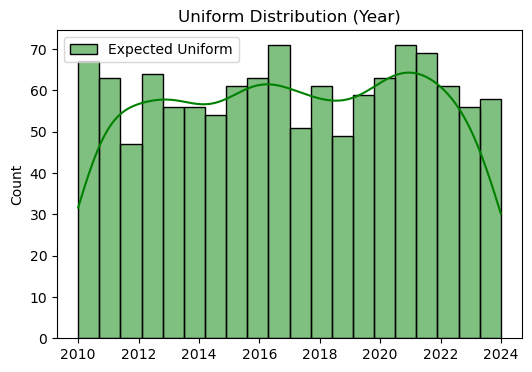

In [32]:
from scipy.stats import uniform
year_range = df["Year"].max() - df["Year"].min()
expected_uniform = uniform.rvs(df["Year"].min(), year_range, size=len(df["Year"]))

plt.figure(figsize=(6, 4))
sns.histplot(expected_uniform, kde=True, bins=20, color='green', label="Expected Uniform")
plt.legend()
plt.title("Uniform Distribution (Year)")
plt.show()

# plt.savefig('Uniform_year.png')
# plt.close()

This code generates a **uniformly distributed dataset** over the range of years in the `'Year'` column, then plots its histogram with a kernel density estimate (**kde=True**)

***Normalization***

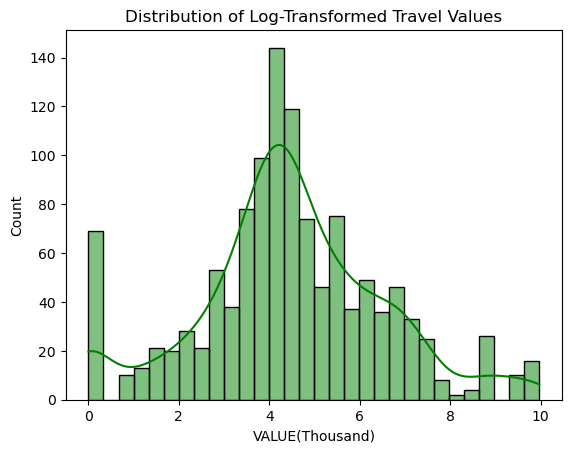

Normality Test for Log-Transformed VALUE: NormaltestResult(statistic=5.288455407059281, pvalue=0.07106021210444086)


In [33]:

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import normaltest

df_log1 = np.log1p(df["VALUE(Thousand)"])

sns.histplot(df_log1, color='green', kde=True, bins=30)
plt.title("Distribution of Log-Transformed Travel Values")
plt.show()

log_normal_test = normaltest(df_log1)
print("Normality Test for Log-Transformed VALUE:", log_normal_test)



# plt.savefig('Normal_test.png')
# plt.close()

The **histogram** represents how travel values are distributed after log transformation. The original data had a lot of small value entries, but very few values were extremely large. After applying the log transformation method, the distribution shows a more normal spread of values with a bell shape emerging. The **KDE (Kernel Density Estimate)** line closely follows the distribution which gives a better fit than the raw data. **The p-value of 0.07106021210444086 is greater than 0.05**, meaning we fail to reject the null hypothesis which indicates that the data follows a **normal distribution**.

***Binomial Distribution***

0.5


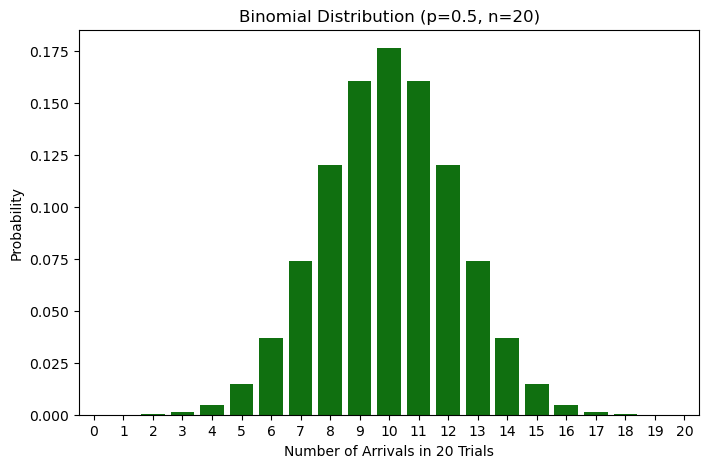

In [34]:
from scipy.stats import binom

direction_counts = df['Direction'].value_counts()
total = direction_counts.sum()
p_arrival = direction_counts["Arrivals"] / total
print(p_arrival)

n = 20  
x = range(n + 1)  
binom_probs = binom.pmf(x, n, p_arrival)  

plt.figure(figsize=(8, 5))
sns.barplot(x=list(x), y=binom_probs, color="green")

plt.xlabel("Number of Arrivals in 20 Trials")
plt.ylabel("Probability")
plt.title(f"Binomial Distribution (p={p_arrival}, n={n})")
plt.xticks(x)

plt.show()

# plt.savefig('Binomial_Distribution_Direction.png')
# plt.close()

This describes a **binomial distribution** where the x-axis shows the number of "Arrivals" in **20 trials**, and the y-axis represents their probabilities. The distribution follows a **binomial pattern**, treating each travel record as a **Bernoulli trial** (Arrivals = success, Departures = failure), with a peak at **10 Arrivals** when **pobability of Arrivals = 0.5**, making it useful for **forecasting future travel trends**.

- binom.pmf(x=(0,21), n=20, p_arrival=0.5) 

***poisson***

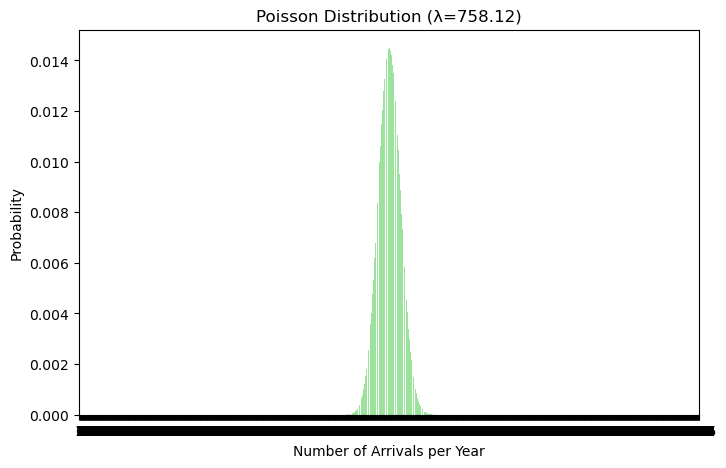

In [35]:
from scipy.stats import poisson

arrivals_df = df[df["Direction"] == "Arrivals"] 

lambda_poisson = arrivals_df["VALUE(Thousand)"].mean() 

x = np.arange(0, int(lambda_poisson * 2)) 

poisson_probs = poisson.pmf(x, lambda_poisson)  

plt.figure(figsize=(8, 5)) 
sns.barplot(x=x, y=poisson_probs, color="lightgreen") 

plt.xlabel("Number of Arrivals per Year") 
plt.ylabel("Probability") 
plt.title(f"Poisson Distribution (λ={lambda_poisson:.2f})") 

plt.show()

# plt.savefig('Poission.png')
# plt.close()

# for the period
# probalibity at certain time


The **Poisson distribution** models the yearly number of arrivals, with **λ (lambda)** representing the average arrivals per year. The x-axis shows arrival counts, while the y-axis represents their probabilities, illustrating that most years have arrivals near λ, with some variation. This model is ideal for **predicting future travel volumes**.


In [70]:
df

,Year,Country,Direction,VALUE(Thousand)
0,2010,All countries,Arrivals,12902
1,2010,All countries,Departures,12920
2,2010,United Arab Emirates,Arrivals,99
3,2010,United Arab Emirates,Departures,99
4,2010,Austria,Arrivals,65
...,...,...,...,...
1195,2024,Other Europe (33),Departures,68
1196,2024,Other Countries(43),Arrivals,1
1197,2024,Other Countries(43),Departures,1
1198,2024,Other transatlantic countries(2),Arrivals,97


### Converting categorical to numerical columns 

In [71]:
import sklearn.preprocessing as preproc

In [72]:
df['Country'].unique()

array(['All countries', 'United Arab Emirates', 'Austria', 'Belgium',
       'Bulgaria', 'Canada', 'Switzerland', 'Cyprus', 'Czech Republic',
       'Germany', 'Denmark', 'Estonia', 'Spain', 'Finland', 'France',
       'Other UK (1)', 'Greece', 'Croatia', 'Hungary', 'Iceland', 'Italy',
       'Lithuania', 'Luxembourg', 'Latvia', 'Malta', 'Netherlands',
       'Norway', 'Poland', 'Portugal', 'Qatar', 'Romania', 'Sweden',
       'Slovenia', 'Slovakia', 'Turkey', 'United States', 'Great Britain',
       'Other Europe (33)', 'Other Countries(43)',
       'Other transatlantic countries(2)'], dtype=object)

In [73]:
le=preproc.LabelEncoder()

In [74]:
df['Country']=le.fit_transform(df['Country'])

In [75]:
len(df['Country'].unique())

40

In [76]:
df['Direction'].unique()

array(['Arrivals', 'Departures'], dtype=object)

In [77]:
df['Direction']=le.fit_transform(df['Direction'])

This code applies **label encoding** the `'Country'`,`'Direction'` columns, converting categorical names into **numerical values** for machine learning

In [78]:
df

,Year,Country,Direction,VALUE(Thousand)
0,2010,0,0,12902
1,2010,0,1,12920
2,2010,38,0,99
3,2010,38,1,99
4,2010,1,0,65
...,...,...,...,...
1195,2024,25,1,68
1196,2024,24,0,1
1197,2024,24,1,1
1198,2024,27,0,97


In [79]:
df['VALUE(Thousand)'] = np.log1p(df['VALUE(Thousand)'])

This code applies **log transformation (`log1p`)** to the `'VALUE'` column to **reduce skewness**, **handle outliers**, and **stabilize variance** by computing **log(1 + VALUE)** to avoid issues with zero values.

In [80]:
df

,Year,Country,Direction,VALUE(Thousand)
0,2010,0,0,9.465215
1,2010,0,1,9.466609
2,2010,38,0,4.605170
3,2010,38,1,4.605170
4,2010,1,0,4.189655
...,...,...,...,...
1195,2024,25,1,4.234107
1196,2024,24,0,0.693147
1197,2024,24,1,0.693147
1198,2024,27,0,4.584967


#### DATA IS READY for ML

## Machine Learning Analysis

In [81]:
X = df[['Year', 'Country', 'Direction']]
y = df['VALUE(Thousand)']

In [82]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [83]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape),
print(X_test.shape),
print(y_train.shape),
print(y_test.shape)

(960, 3)
(240, 3)
(960,)
(240,)


Model Development
- The feature matrix (X) consisted of temporal variables (year, Countries, Direction). The target variable (y) was the count of passengers. 
- Train-test split (80:20) ensured unbiased model evaluation. 
- Models were trained and tested using the regression suite from sklearn.


In [96]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

 Polynomial features of degree 2 were created to capture the non-linearities in the data so that the model can be trained on squared and interaction terms of the original features.

#### Model 1: Linear Regression model

In [97]:
from sklearn.linear_model import LinearRegression

In [98]:
lr_model = LinearRegression()
lr_model.fit(X_train_poly, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [106]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lr_pred = lr_model.predict(X_test_poly)
lr_mae = mean_absolute_error(y_test, lr_pred)  
lr_mse = mean_squared_error(y_test, lr_pred)  
lr_rmse = np.sqrt(lr_mse)  
lr_r2 = r2_score(y_test, lr_pred) 

print(f'Mean Absolute Error (MAE): {lr_mae}')
print(f'Mean Squared Error (MSE): {lr_mse}')
print(f'Root Mean Squared Error (RMSE): {lr_rmse}')
print(f'R-squared (R2): {lr_r2}')


Mean Absolute Error (MAE): 1.4922308773912036
Mean Squared Error (MSE): 3.8674499561143914
Root Mean Squared Error (RMSE): 1.9665833204098908
R-squared (R2): 0.10132071063011039


#### Model 2: Random Forest with Hyperparameter Tuning

In [107]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

In [108]:
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

In [109]:
rf_model = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(rf_model, param_grid, cv=5, scoring='r2')
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;-

best_estimator_: RandomForestRegressor


- RandomForestRegressor(max_depth=20, n_estimators=150, random_state=42)

In [110]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

best_rf_model = grid_search.best_estimator_
rf_pred = best_rf_model.predict(X_test)
rf_mae = mean_absolute_error(y_test, rf_pred)  
rf_mse = mean_squared_error(y_test, rf_pred)  
rf_rmse = np.sqrt(rf_mse)  
rf_r2 = r2_score(y_test, rf_pred) 

print(f'Mean Absolute Error (MAE): {rf_mae}')
print(f'Mean Squared Error (MSE): {rf_mse}')
print(f'Root Mean Squared Error (RMSE): {rf_rmse}')
print(f'R-squared (R2): {rf_r2}')


Mean Absolute Error (MAE): 0.1277243373071716
Mean Squared Error (MSE): 0.040271115802704496
Root Mean Squared Error (RMSE): 0.20067664488600684
R-squared (R2): 0.9906422014137534


#### Model 3: Gradient Boosting Regressor

In [111]:
gb_model = GradientBoostingRegressor()
gb_model.fit(X_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

In [112]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

gb_pred = gb_model.predict(X_test)

gb_mae = mean_absolute_error(y_test, gb_pred)  
gb_mse = mean_squared_error(y_test, gb_pred)  
gb_rmse = np.sqrt(gb_mse)  
gb_r2 = r2_score(y_test, gb_pred) 

print(f'Mean Absolute Error (MAE): {gb_mae}')
print(f'Mean Squared Error (MSE): {gb_mse}')
print(f'Root Mean Squared Error (RMSE): {gb_rmse}')
print(f'R-squared (R2): {gb_r2}')


Mean Absolute Error (MAE): 0.5131753476036908
Mean Squared Error (MSE): 0.5593337817044366
Root Mean Squared Error (RMSE): 0.7478862090615367
R-squared (R2): 0.8700276173792465


### Comparison Table & Scatter plots

In [113]:
results = {
    'Model': ['Linear Regression (Poly)', 'Random Forest', 'Gradient Boosting'],
    'R2 Score': [lr_r2, rf_r2, gb_r2],
    'MAE': [lr_mae, rf_mae, gb_mae],
    'MSE': [lr_mse, rf_mse, gb_mse],
    'RMSE': [lr_rmse, rf_rmse, gb_rmse]
}

comparison_df = pd.DataFrame(results)
print(comparison_df)


                      Model  R2 Score       MAE       MSE      RMSE
0  Linear Regression (Poly)  0.101321  1.492231  3.867450  1.966583
1             Random Forest  0.990642  0.127724  0.040271  0.200677
2         Gradient Boosting  0.870028  0.513175  0.559334  0.747886


The evaluation results show that Random Forest turns out to be the best model in terms of prediction accuracy, as it has the highest R² score (0.9906) and very low errors, then followed by Gradient Boosting with a fairly acceptable performance, while Linear Regression (Polynomial) did not perform well and is not able to capture the variance of the data.

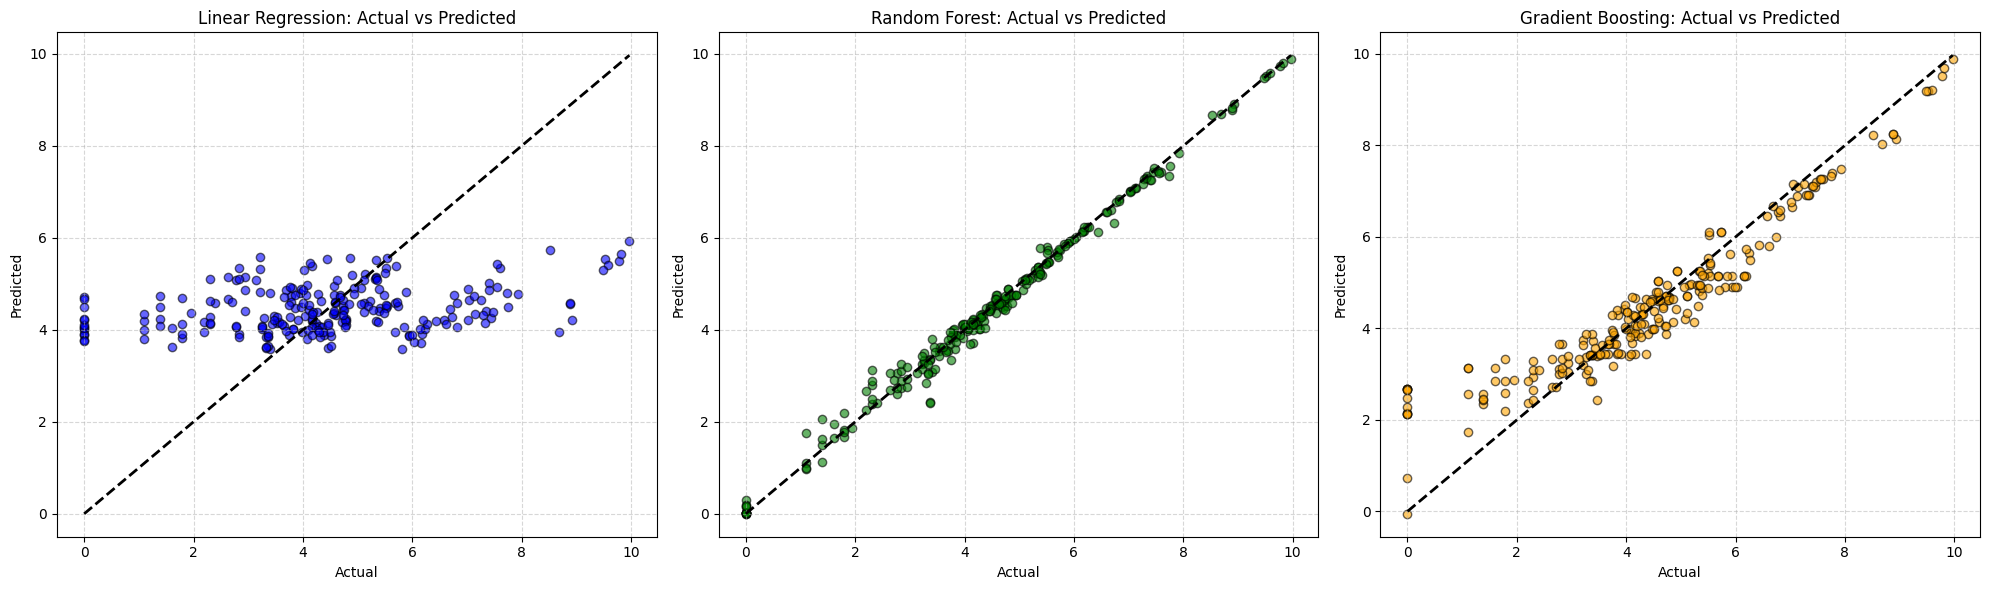

In [114]:
plt.figure(figsize=(20, 6)) 

# Linear Regression
plt.subplot(1, 3, 1) 
plt.scatter(y_test, lr_pred, color="blue", alpha=0.6, edgecolors="black")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "k--", lw=2)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Linear Regression: Actual vs Predicted")
plt.grid(True, linestyle="--", alpha=0.5)

# Random Forest
plt.subplot(1, 3, 2) 
plt.scatter(y_test, rf_pred, color="green", alpha=0.6, edgecolors="black")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "k--", lw=2)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Random Forest: Actual vs Predicted")
plt.grid(True, linestyle="--", alpha=0.5)

# Gradient Boosting
plt.subplot(1, 3, 3) 
plt.scatter(y_test, gb_pred, color="orange", alpha=0.6, edgecolors="black")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "k--", lw=2)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Gradient Boosting: Actual vs Predicted")
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


# plt.savefig('ScatterML.png')
# plt.close()

The scatter plots visually confirm the models' performances: 
- Linear Regression (Polynomial) shows poor prediction accuracy with widely scattered points 
- Random Forest aligns closely with the diagonal, reflecting its high R² score and precision 
- Gradient Boosting demonstrates a strong but slightly less accurate fit compared to Random Forest.

Random Forest Regressor would then become the best of the list of possible Machine Learning models for this study due to how well it holds an accuracy of 0.99 for the R² score. Thus, almost all variance in the data and predictions relate to the passengers. Developments in this respect led to a more robust trend in the forecasting of travel activities, which in turn would supplement effective tourism planning and resource allocation activities.

### Model Perfromance Comparison

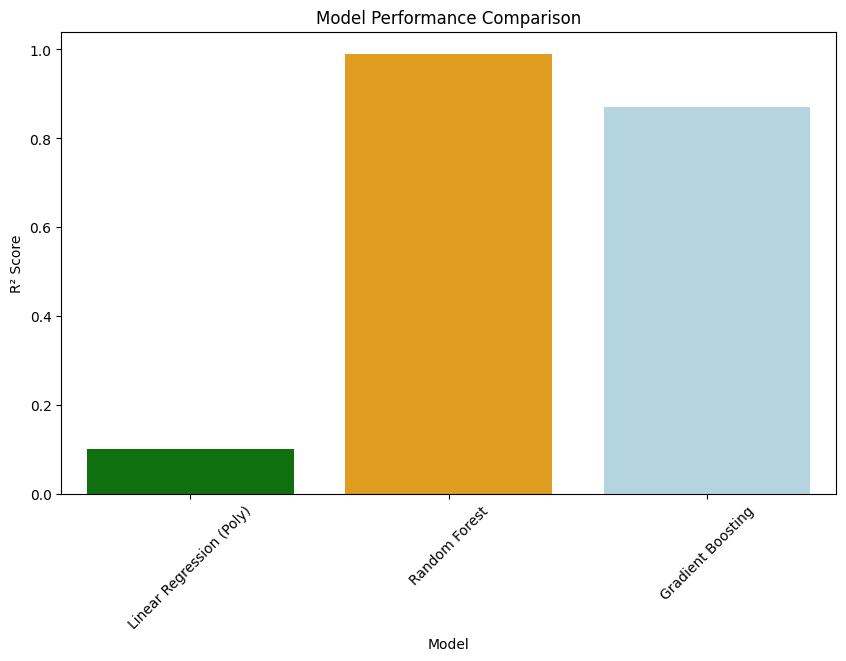

In [115]:
plt.figure(figsize=(10, 6))
sns.barplot(x=comparison_df['Model'], y=comparison_df['R2 Score'], palette=['green', 'orange', 'lightblue'])

plt.title('Model Performance Comparison')
plt.ylabel('R² Score')
plt.xlabel('Model')
plt.xticks(rotation=45)

plt.show()

# plt.savefig('ComparisonML.png')
# plt.close()

Bar graph presents that Random Forest model performs the best in terms of R² score, following Gradient Boosting with slightly less strength and accuracy, whereas Linear Regression(Polynomial) scored poorly, rendering it useless for this dataset.

In [117]:
feature_importances = pd.DataFrame({
        'Feature': X.columns,
        'Importance': best_rf_model.feature_importances_
    }).sort_values('Importance', ascending=False)
feature_importances

,Feature,Importance
1,Country,0.885818
0,Year,0.113002
2,Direction,0.001180


### Feature Importance

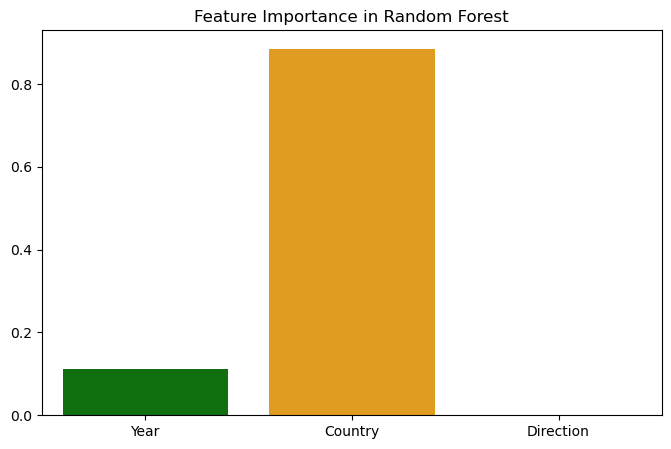

In [64]:
feature_importances = best_rf_model.feature_importances_
plt.figure(figsize=(8,5))
sns.barplot(x=X.columns, y=feature_importances,palette=['green', 'orange', 'lightblue'])
plt.title('Feature Importance in Random Forest')
plt.show()

# plt.savefig('FeatureML_RF.png')
# plt.close()

the feature importance analysis, it is evident that the Random Forest model gives most weight to the feature "Country" and secondly to "Year"; "Direction" has almost negligible importance, thus affording "Country" as the most dominant predictor in the model.